#**Creación de una red neuronal aplicando el concepto GAN**

#Importar Librerías

In [1]:
!pip install tensorflow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

epocas=1000
batch_size=64
noise_dim=100

#Carga del Dataset

In [2]:
(X_train, _), (_, _)=keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#Normalización

In [3]:
X_train=X_train.astype("float32")
x_train=(X_train-127.5)/127.5

#Aplanar Imágenes

In [4]:
X_train=X_train.reshape(X_train.shape[0],784)

#**Construir el Generador**

In [5]:
def build_generator():
  model=keras.Sequential([
      layers.Dense(128, activation='relu', input_dim=100),
      layers.Dense(256, activation='relu'),
      layers.Dense(512, activation='relu'),
      layers.Dense(784, activation='tanh')
  ])
  return model

#**Construir Discriminador**

In [6]:
def build_discriminator():
  model=keras.Sequential([
      layers.Dense(512, activation='relu', input_dim=784),
      layers.Dense(256, activation='relu'),
      layers.Dense(1, activation='sigmoid')
  ])

  model.compile(
      optimizer='adam',
      loss='binary_crossentropy',
      metrics=['accuracy']
  )

  return model

#Creación de modelos

In [7]:
generador=build_generator()

discriminador=build_discriminator()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#**Congelar Discriminador**

Se debe congelar de forma temporal mientras se entrena el generador

In [8]:
discriminador.trainable=False

#Construir la GAN

In [9]:
gan_input=keras.Input(shape=(100,))
generated_image=generador(gan_input)
gan_output=discriminador(generated_image)

gan=keras.Model(gan_input,gan_output)

#Compilar

In [10]:
gan.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

#**Entrenamiento Adversarial**

In [11]:
for epoch in range(epocas):
  '''
  ###############################
  Entrenamiento del Discriminador
  ################################
  '''

  idx=np.random.randint(0,X_train.shape[0],batch_size)
  real_images=X_train[idx]

  noise=np.random.normal(0,1, (batch_size,noise_dim))
  fake_images=generador.predict(noise, verbose=0)

  real_labels=np.ones((batch_size,1))
  fake_labels=np.zeros((batch_size,1))

  d_loss_real=discriminador.train_on_batch(real_images, real_labels)
  d_loss_fake=discriminador.train_on_batch(fake_images, fake_labels)

  '''
  ###############################
  Entrenamiento del Generador
  ################################
  '''
  noise=np.random.normal(0,1,(batch_size, noise_dim))

  misleading_labels=np.ones((batch_size,1))

  g_loss=gan.train_on_batch(noise, misleading_labels)

  if epoch%100==0:
    print(f"Epoca {epoch}")

    print(f"Discriminator Loss: {d_loss_real[0]}")

    print(f"Generator Loss: {g_loss}")

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoca 0
Discriminator Loss: 1.5366158699399496e-17
Generator Loss: 0.6655042171478271
Epoca 100
Discriminator Loss: 6.682803630828857
Generator Loss: 0.010274041444063187
Epoca 200
Discriminator Loss: 6.959992408752441
Generator Loss: 0.0051628174260258675
Epoca 300
Discriminator Loss: 7.055146217346191
Generator Loss: 0.0034477540757507086
Epoca 400
Discriminator Loss: 7.1061177253723145
Generator Loss: 0.00258808396756649
Epoca 500
Discriminator Loss: 7.139139175415039
Generator Loss: 0.0020715955179184675
Epoca 600
Discriminator Loss: 7.1634650230407715
Generator Loss: 0.0017269833479076624
Epoca 700
Discriminator Loss: 7.1828508377075195
Generator Loss: 0.0014806914841756225
Epoca 800
Discriminator Loss: 7.199645519256592
Generator Loss: 0.0012958955485373735
Epoca 900
Discriminator Loss: 7.2144622802734375
Generator Loss: 0.0011521194828674197


#**Visualización de las Imágenes**

In [12]:
noise=np.random.normal(0,1,(10,noise_dim))
generated_images=generador.predict(noise)

#Revertir Escala

generated_images=0.5 * generated_images + 0.5

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step


Mostrar

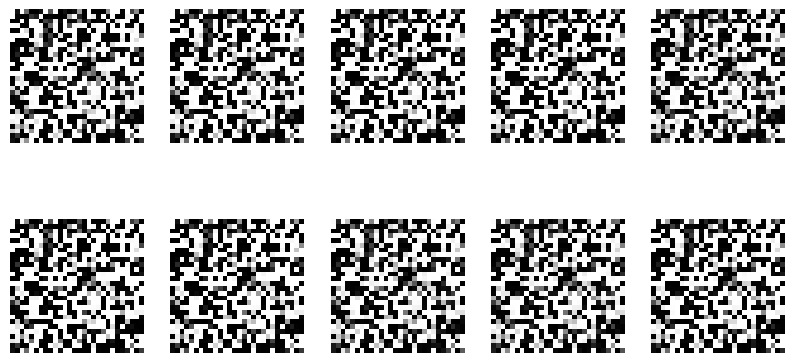

In [13]:
plt.figure(figsize=(10,5))

for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(generated_images[i].reshape(28,28), cmap='gray')
  plt.axis('off')

plt.show()
